

<div style="background: linear-gradient(120deg, #1ca9c9 0%, #40c4d6 60%, #7fe0e0 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Actividad 5: Comprensión de los Datos</h1>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Laboratorio de Procesamiento de Datos</h3>
    </div>
</div>



### Ejercicio 1. Taxonomía y calidad de datos: Palmer Penguins

**Dataset:** [Palmer Penguins CSV](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv)

1. Carga el CSV y describe sus dimensiones, tipos, faltantes y duplicados.
2. Clasifica cada columna como nominal, ordinal, binaria, discreta o continua. Justifica cualquier caso discutible.
3. Calcula cardinalidad, proporción de cada categoría y moda para las variables categóricas.
4. Compara `species`, `island` y `sex` con tablas de frecuencia y gráficas apropiadas.
5. Analiza los faltantes de `sex`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g`. Propón una estrategia, pero no la apliques sin justificarla.
6. Explica por qué `species` no debe codificarse como `1, 2, 3` si el modelo interpreta esos valores como cantidades.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

#### 1.1 Dimensiones, tipos, faltantes y duplicados

In [25]:
penguins = pd.read_csv("/Users/matmtz/Desktop/GitHub/Laboratorio_de_Procesamiento_de_Datos_02026/Modulo I/Data/penguins.csv")
print(f"Dimensiones: {penguins.shape[0]} filas x {penguins.shape[1]} columnas\n")
penguins.head()

Dimensiones: 344 filas x 8 columnas



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.100,18.700,181.000,3750.000,male,2007
1,Adelie,Torgersen,39.500,17.400,186.000,3800.000,female,2007
2,Adelie,Torgersen,40.300,18.000,195.000,3250.000,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.700,19.300,193.000,3450.000,female,2007


In [26]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 27.6 KB


In [27]:
faltantes = pd.DataFrame({
    "faltantes": penguins.isna().sum(),
    "% faltantes": penguins.isna().mean() * 100,
})
display(faltantes)

n_incompletas = penguins.isna().any(axis=1).sum()
print(f"Filas duplicadas: {penguins.duplicated().sum()}")
print(f"Filas con al menos un faltante: {n_incompletas} de {len(penguins)}")

,faltantes,% faltantes
species,0,0.000
island,0,0.000
bill_length_mm,2,0.581
bill_depth_mm,2,0.581
flipper_length_mm,2,0.581
body_mass_g,2,0.581
sex,11,3.198
year,0,0.000


Filas duplicadas: 0
Filas con al menos un faltante: 11 de 344


- **Dimensiones:** 344 filas × 8 columnas.
- **Tipos:** species, island y sex son texto; bill_length_mm, bill_depth_mm, flipper_length_mm y body_mass_g son float64; year es entero.
- **Faltantes:** sex tiene 11 (3.2 %) y cada una de las cuatro mediciones corporales tiene 2 (0.58 %). En total hay 11 filas con algún faltante y 333 completas.
- **Duplicados:** no hay filas duplicadas.


#### 1.2 Clasificación de las columnas

In [28]:
clasificacion = pd.DataFrame([
    ("species", "Nominal",
     "Tres etiquetas (Adelie, Chinstrap, Gentoo) sin orden natural."),
    ("island", "Nominal",
     "Tres lugares (Biscoe, Dream, Torgersen) sin orden natural."),
    ("sex", "Binaria",
     "Solo dos categorías (female, male)."),
    ("bill_length_mm", "Continua",
     "Longitud en mm; puede tomar cualquier valor real (aparece con decimales)."),
    ("bill_depth_mm", "Continua",
     "Profundidad del pico en mm; puede tomar cualquier valor real (aparece con decimales)."),
    ("flipper_length_mm", "Continua",
     "Solo contiene enteros y parece discreta, pero es una longitud: el redondeo viene del instrumento de medición, "
     "no de la naturaleza de la variable."),
    ("body_mass_g", "Continua",
     "Solo contiene enteros (múltiplos de 25 g) por la resolución de la balanza; la masa es intrínsecamente continua."),
    ("year", "Discreta",
     "Solo toma 2007, 2008 y 2009. Tiene orden temporal, pero funciona como identificador de la campaña de muestreo, "
     "no como una cantidad con la que se pueda operar."),
], columns=["columna", "clasificación", "justificación"]).set_index("columna")
clasificacion

,clasificación,justificación
columna,,
species,Nominal,"Tres etiquetas (Adelie, Chinstrap, Gentoo) sin orden natural."
island,Nominal,"Tres lugares (Biscoe, Dream, Torgersen) sin orden natural."
sex,Binaria,"Solo dos categorías (female, male)."
bill_length_mm,Continua,Longitud en mm; puede tomar cualquier valor real (aparece con decimales).
bill_depth_mm,Continua,Profundidad del pico en mm; puede tomar cualquier valor real (aparece con decimales).
flipper_length_mm,Continua,"Solo contiene enteros y parece discreta, pero es una longitud: el redondeo viene del instrumento de medición, no de la naturaleza de la variable."
body_mass_g,Continua,Solo contiene enteros (múltiplos de 25 g) por la resolución de la balanza; la masa es intrínsecamente continua.
year,Discreta,"Solo toma 2007, 2008 y 2009. Tiene orden temporal, pero funciona como identificador de la campaña de muestreo, no como una cantidad con la que se pueda operar."


#### 1.3 Cardinalidad, proporciones y moda de las variables categóricas

In [29]:
cat_cols = ["species", "island", "sex"]

filas = []
for c in cat_cols:
    vc = penguins[c].value_counts()
    filas.append({
        "variable": c,
        "cardinalidad": penguins[c].nunique(),
        "moda": vc.idxmax(),
        "frecuencia de la moda": vc.max(),
        "proporción de la moda": vc.max() / vc.sum(),
    })
pd.DataFrame(filas).set_index("variable")

,cardinalidad,moda,frecuencia de la moda,proporción de la moda
variable,,,,
species,3,Adelie,152,0.442
island,3,Biscoe,168,0.488
sex,2,male,168,0.505


In [30]:
for c in cat_cols:
    n = penguins[c].value_counts(dropna=False)
    tabla = pd.DataFrame({
        "n": n,
        "proporción (sobre todas las filas)": n / len(penguins),
        "proporción (sobre válidos)": penguins[c].value_counts(normalize=True).reindex(n.index),
    })
    tabla.index.name = c
    display(tabla)

,n,proporción (sobre todas las filas),proporción (sobre válidos)
species,,,
Adelie,152,0.442,0.442
Gentoo,124,0.360,0.360
Chinstrap,68,0.198,0.198


,n,proporción (sobre todas las filas),proporción (sobre válidos)
island,,,
Biscoe,168,0.488,0.488
Dream,124,0.360,0.360
Torgersen,52,0.151,0.151


,n,proporción (sobre todas las filas),proporción (sobre válidos)
sex,,,
male,168,0.488,0.505
female,165,0.480,0.495
NaN,11,0.032,NaN


- **species:** cardinalidad 3; moda Adelie (152, 44.2 %), luego Gentoo (124, 36.0 %) y Chinstrap (68, 19.8 %).
- **island:** cardinalidad 3; moda Biscoe (168, 48.8 %), luego Dream (124, 36.0 %) y Torgersen (52, 15.1 %).
- **sex:** cardinalidad 2; moda male (168), con 165 female. Sobre los 333 valores válidos son 50.5 % y 49.5 %; con los 11 faltantes incluidos, las proporciones son 48.8 %, 48.0 % y 3.2 % (faltante).


#### 1.4 Comparación de `species`, `island` y `sex`

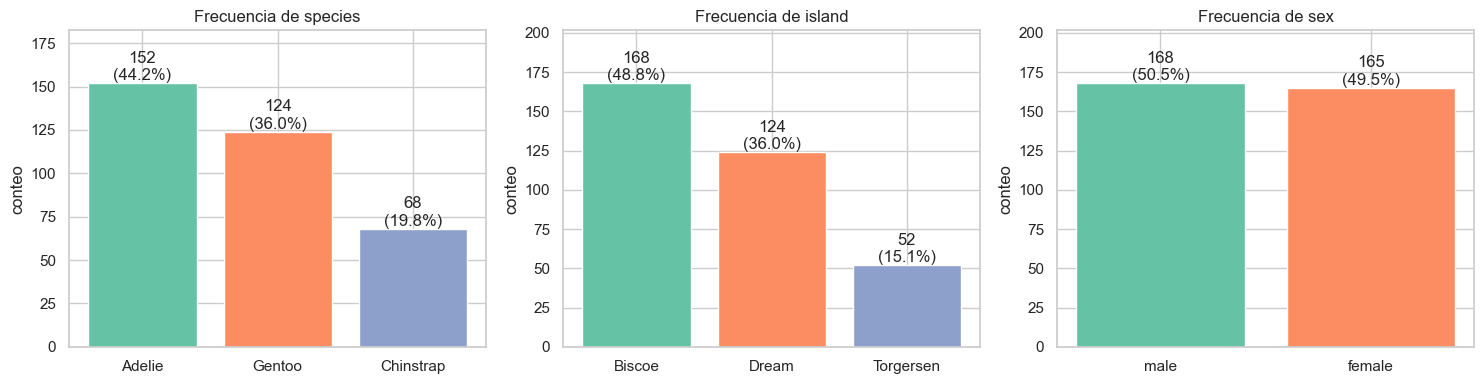

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colores = sns.color_palette("Set2")
for ax, c in zip(axes, cat_cols):
    conteo = penguins[c].value_counts()
    barras = ax.bar(conteo.index, conteo.values, color=colores[:len(conteo)])
    ax.bar_label(barras, labels=[f"{v}\n({v / conteo.sum():.1%})" for v in conteo.values])
    ax.set_title(f"Frecuencia de {c}")
    ax.set_ylabel("conteo")
    ax.set_ylim(0, conteo.max() * 1.2)
fig.tight_layout()
plt.show()

In [32]:
for a, b in [("species", "island"), ("species", "sex"), ("island", "sex")]:
    print(f"{a} x {b}")
    display(pd.crosstab(penguins[a], penguins[b], margins=True, margins_name="Total"))

species x island


island,Biscoe,Dream,Torgersen,Total
species,,,,
Adelie,44,56,52,152
Chinstrap,0,68,0,68
Gentoo,124,0,0,124
Total,168,124,52,344


species x sex


sex,female,male,Total
species,,,
Adelie,73,73,146
Chinstrap,34,34,68
Gentoo,58,61,119
Total,165,168,333


island x sex


sex,female,male,Total
island,,,
Biscoe,80,83,163
Dream,61,62,123
Torgersen,24,23,47
Total,165,168,333


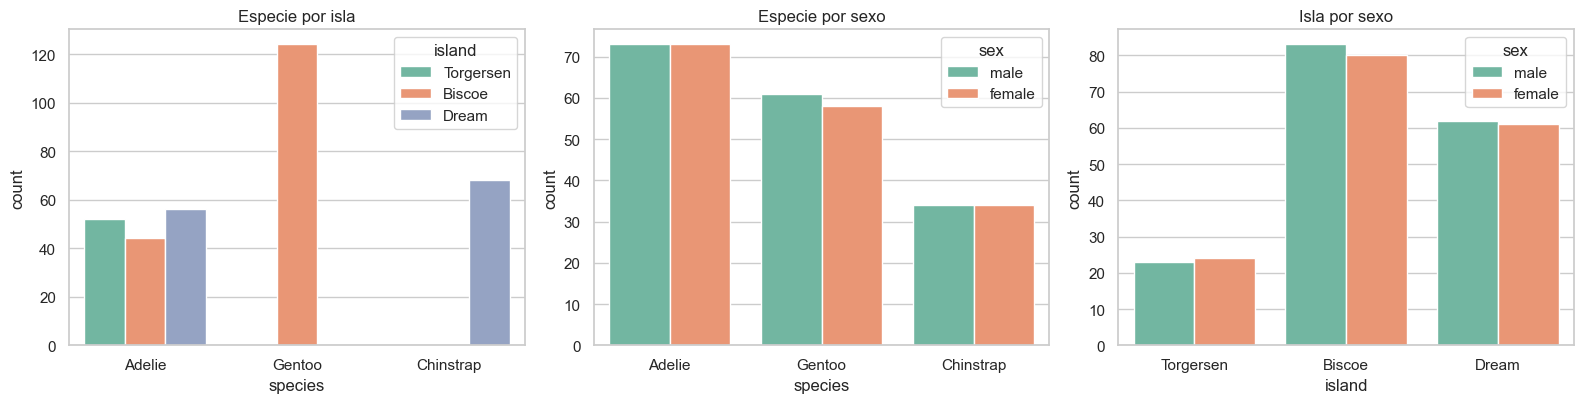

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.countplot(data=penguins, x="species", hue="island", ax=axes[0])
axes[0].set_title("Especie por isla")
sns.countplot(data=penguins, x="species", hue="sex", ax=axes[1])
axes[1].set_title("Especie por sexo")
sns.countplot(data=penguins, x="island", hue="sex", ax=axes[2])
axes[2].set_title("Isla por sexo")
fig.tight_layout()
plt.show()

- **species × island:** las categorías están muy entrelazadas. **Gentoo solo aparece en Biscoe** (124) y **Chinstrap solo en Dream** (68); solo Adelie está en las tres islas (44 en Biscoe, 56 en Dream y 52 en Torgersen), y Torgersen solo tiene Adelie. Por eso island aporta información en buena medida redundante con species.
- **sex:** está balanceada dentro de cada especie y de cada isla (por ejemplo, Adelie 73 hembras y 73 machos, Chinstrap 34 y 34; Biscoe 80 y 83, Dream 61 y 62, Torgersen 24 y 23).
- **Gráficas:** las barras simples comparan la frecuencia de las categorías de una sola variable; las barras agrupadas (hue) muestran cómo se reparte una variable dentro de otra y hacen evidente que casi todas las combinaciones species–island están vacías, mientras que sex se reparte parejo.


#### 1.5 Análisis de faltantes y estrategia

In [34]:
medidas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
cols_faltantes = ["sex"] + medidas
faltan = penguins[cols_faltantes].isna()

print("Faltantes por columna:")
display(pd.DataFrame({"faltantes": faltan.sum(), "% del total": faltan.mean() * 100}))

print("Patrones de faltantes (True = valor ausente):")
display(faltan.value_counts().rename("filas").reset_index())

print("Filas con algún faltante:")
display(penguins[faltan.any(axis=1)])

Faltantes por columna:


,faltantes,% del total
sex,11,3.198
bill_length_mm,2,0.581
bill_depth_mm,2,0.581
flipper_length_mm,2,0.581
body_mass_g,2,0.581


Patrones de faltantes (True = valor ausente):


,sex,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,filas
0,False,False,False,False,False,333
1,True,False,False,False,False,9
2,True,True,True,True,True,2


Filas con algún faltante:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,Adelie,Torgersen,34.100,18.100,193.000,3475.000,NaN,2007
9,Adelie,Torgersen,42.000,20.200,190.000,4250.000,NaN,2007
10,Adelie,Torgersen,37.800,17.100,186.000,3300.000,NaN,2007
11,Adelie,Torgersen,37.800,17.300,180.000,3700.000,NaN,2007
47,Adelie,Dream,37.500,18.900,179.000,2975.000,NaN,2007
178,Gentoo,Biscoe,44.500,14.300,216.000,4100.000,NaN,2007
218,Gentoo,Biscoe,46.200,14.400,214.000,4650.000,NaN,2008
256,Gentoo,Biscoe,47.300,13.800,216.000,4725.000,NaN,2009
268,Gentoo,Biscoe,44.500,15.700,217.000,4875.000,NaN,2009


In [35]:
# ¿En qué grupos se concentran los faltantes de sex?
sex_na = penguins["sex"].isna()
for g in ["species", "island", "year"]:
    ct = pd.crosstab(penguins[g], sex_na).rename(columns={False: "con sexo", True: "sin sexo"})
    ct["% sin sexo"] = ct["sin sexo"] / ct.sum(axis=1) * 100
    display(ct)

sex,con sexo,sin sexo,% sin sexo
species,,,
Adelie,146,6,3.947
Chinstrap,68,0,0.000
Gentoo,119,5,4.032


sex,con sexo,sin sexo,% sin sexo
island,,,
Biscoe,163,5,2.976
Dream,123,1,0.806
Torgersen,47,5,9.615


sex,con sexo,sin sexo,% sin sexo
year,,,
2007,103,7,6.364
2008,113,1,0.877
2009,117,3,2.500


**Análisis de los faltantes**

- **Las mediciones fallan en bloque.** Solo hay tres patrones: 333 filas completas, **9 filas donde falta únicamente `sex`** y **2 filas donde faltan las cinco columnas a la vez**. Es decir, los faltantes de `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g` son las mismas dos filas, aves a las que no se les midió nada.
- **Los faltantes de `sex` se concentran en ciertos grupos:** Torgersen (5 de 52 = 9.6 %, contra 0.8 % en Dream), 2007 (7 de los 11) y no hay ninguno en Chinstrap. Sugiere que dependen de cómo se recogieron los datos (isla y año) y no de un azar uniforme, aunque con solo 11 casos es una señal exploratoria.

**Estrategia propuesta y su justificación**

| Caso | Propuesta | Justificación |
|---|---|---|
| 2 filas sin ninguna medición (0.58 %) | Eliminarlas | Solo conservan especie, isla y año; no hay información con qué imputarlas de forma honesta y su pérdida es mínima. |
| 9 filas con solo `sex` faltante | No imputar con la moda. Conservarlas y decidir según el análisis | Tienen las cuatro mediciones completas, así que eliminarlas desperdicia información. Imputar con la moda asignaría un sexo casi al azar (≈ 50/50) y debilitaría artificialmente la relación entre sexo y tamaño. |
| Análisis descriptivo de las mediciones | Usar todas las filas con dato en esa columna | No requiere `sex`. |
| Análisis por sexo | Excluir esas 9 filas solo en ese análisis | Sin la variable de interés no pueden entrar. |
| Modelo que use `sex` como variable | Crear una categoría "desconocido" o imputar con un modelo (a partir de especie, isla y año) dentro de la validación cruzada | Evita fuga de información. |


#### 1.6 ¿Por qué `species` no debe codificarse como 1, 2, 3?

Codificar `species` como 1, 2, 3 le dice al modelo que las especies son **cantidades con orden y separaciones iguales**, y eso es falso, porque `species` es nominal:

- **Impone un orden que no existe.** Con Adelie = 1, Chinstrap = 2 y Gentoo = 3, el modelo asume que Chinstrap está "entre" Adelie y Gentoo, y que Gentoo es "el triple" de Adelie. Ese orden solo viene del alfabeto.
- **Impone distancias falsas.** La distancia entre Adelie y Gentoo (2) sería el doble que entre Adelie y Chinstrap (1), y el promedio de Adelie y Gentoo daría "Chinstrap". Los modelos basados en distancias (k-NN, k-means) o en coeficientes lineales usarían esa geometría inventada.
- **El resultado depende de una asignación arbitraria.** Cambiar qué especie recibe qué número cambia lo que el modelo aprende, aunque la información sea exactamente la misma.
- **Alternativa:** codificación *one-hot* (una columna 0/1 por especie). Así las tres especies quedan a la misma distancia entre sí y cada una puede tener su propio efecto; en modelos lineales se elimina una columna para evitar colinealidad perfecta. La codificación 1, 2, 3 solo es adecuada cuando la variable **sí** tiene un orden natural (ordinal).


### Ejercicio 2. Distribuciones y transformación: propinas en restaurantes

**Dataset:** [Seaborn Tips CSV](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv)

1. Carga el dataset y describe las variables `total_bill`, `tip`, `size`, `day`, `time` y `smoker`.
2. Para `total_bill` y `tip`, calcula media, mediana, moda, desviación estándar, rango intercuartílico, asimetría y curtosis excedente.
3. Construye histogramas, diagramas de caja. Compara qué información aporta cada gráfico.
4. Compara la distribución de `total_bill` entre `time` y entre `day`. Usa estadísticas y visualizaciones.
5. Aplica una transformación logarítmica a `total_bill` y compara asimetría, histograma y gráfico Q-Q antes y después.
6. Explica por qué `size` debe analizarse como conteo discreto y no como una variable continua cualquiera.


#### 2.1 Carga y descripción de las variables

In [36]:
tips = pd.read_csv("/Users/matmtz/Desktop/GitHub/Laboratorio_de_Procesamiento_de_Datos_02026/Modulo I/Data/tips.csv")
variables = ["total_bill", "tip", "size", "day", "time", "smoker"]
print(f"Dimensiones: {tips.shape[0]} filas x {tips.shape[1]} columnas\n")
tips[variables].info()

Dimensiones: 244 filas x 7 columnas

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   size        244 non-null    int64  
 3   day         244 non-null    str    
 4   time        244 non-null    str    
 5   smoker      244 non-null    str    
dtypes: float64(2), int64(1), str(3)
memory usage: 14.3 KB


In [37]:
descripcion = pd.DataFrame([
    ("total_bill", "Continua (USD)", "Monto total de la cuenta."),
    ("tip", "Continua (USD)", "Propina."),
    ("size", "Discreta (conteo)", "Número de personas en la mesa."),
    ("day", "Nominal", "Día de la semana (Thur, Fri, Sat, Sun)."),
    ("time", "Binaria", "Turno: Lunch o Dinner."),
    ("smoker", "Binaria", "Si el grupo es fumador (Yes / No)."),
], columns=["variable", "tipo", "descripción"]).set_index("variable")
display(descripcion)

print("Variables numéricas:")
display(tips[["total_bill", "tip", "size"]].describe().T)

for c in ["day", "time", "smoker"]:
    n = tips[c].value_counts()
    display(pd.DataFrame({"n": n, "proporción": n / n.sum()}).rename_axis(c))

,tipo,descripción
variable,,
total_bill,Continua (USD),Monto total de la cuenta.
tip,Continua (USD),Propina.
size,Discreta (conteo),Número de personas en la mesa.
day,Nominal,"Día de la semana (Thur, Fri, Sat, Sun)."
time,Binaria,Turno: Lunch o Dinner.
smoker,Binaria,Si el grupo es fumador (Yes / No).


Variables numéricas:


,count,mean,std,min,25%,50%,75%,max
total_bill,244.000,19.786,8.902,3.070,13.348,17.795,24.127,50.810
tip,244.000,2.998,1.384,1.000,2.000,2.900,3.562,10.000
size,244.000,2.570,0.951,1.000,2.000,2.000,3.000,6.000


,n,proporción
day,,
Sat,87,0.357
Sun,76,0.311
Thur,62,0.254
Fri,19,0.078


,n,proporción
time,,
Dinner,176,0.721
Lunch,68,0.279


,n,proporción
smoker,,
No,151,0.619
Yes,93,0.381


**Análisis**

- **Estructura:** 244 mesas y sin faltantes en las variables analizadas.
- **`total_bill`** (continua, USD): media 19.79, desviación 8.90, de 3.07 a 50.81. **`tip`** (continua, USD): media 3.00, de 1.00 a 10.00.
- **`size`** (discreta, conteo de personas): de 1 a 6, con media 2.57 y mediana 2.
- **`day`** (nominal): sábado 87 (35.7 %), domingo 76 (31.1 %), jueves 62 (25.4 %) y viernes 19 (7.8 %).
- **`time`** (binaria): 176 cenas (72.1 %) y 68 almuerzos (27.9 %).
- **`smoker`** (binaria): 151 No (61.9 %) y 93 Yes (38.1 %).


#### 2.2 Estadísticos de `total_bill` y `tip`

In [38]:
def resumen(x):
    q1, q3 = x.quantile([0.25, 0.75])
    return pd.Series({
        "media": x.mean(),
        "mediana": x.median(),
        "moda": x.mode().iloc[0],
        "desviación estándar": x.std(ddof=1),
        "RIC (Q3 - Q1)": q3 - q1,
        "asimetría": stats.skew(x, bias=False),
        "curtosis excedente": stats.kurtosis(x, fisher=True, bias=False),
    })

display(tips[["total_bill", "tip"]].apply(resumen))

for c in ["total_bill", "tip"]:
    moda = tips[c].mode().iloc[0]
    print(f"{c}: moda = {moda}, aparece {(tips[c] == moda).sum()} veces de {len(tips)}")

,total_bill,tip
media,19.786,2.998
mediana,17.795,2.900
moda,13.420,2.000
desviación estándar,8.902,1.384
RIC (Q3 - Q1),10.780,1.562
asimetría,1.133,1.465
curtosis excedente,1.218,3.648


total_bill: moda = 13.42, aparece 3 veces de 244
tip: moda = 2.0, aparece 33 veces de 244


**Análisis**

| | media | mediana | moda | desv. est. | RIC | asimetría | curtosis excedente |
|---|---|---|---|---|---|---|---|
| `total_bill` | 19.79 | 17.80 | 13.42 | 8.90 | 10.78 | 1.13 | 1.22 |
| `tip` | 3.00 | 2.90 | 2.00 | 1.38 | 1.56 | 1.47 | 3.65 |

- **Asimetría positiva en ambas:** la media es mayor que la mediana porque unos pocos valores altos jalan la media hacia la derecha.
- **Curtosis excedente positiva:** colas más pesadas que las de una normal, especialmente en `tip` (3.65).
- **Moda:** en `total_bill` aparece solo 3 veces de 244 y no es informativa; en `tip` la moda (2.00) aparece 33 veces, porque la gente redondea las propinas a cifras "bonitas".
- **RIC:** al basarse en cuartiles, no se ve afectado por los valores extremos, a diferencia de la desviación estándar.


#### 2.3 Histogramas y diagramas de caja

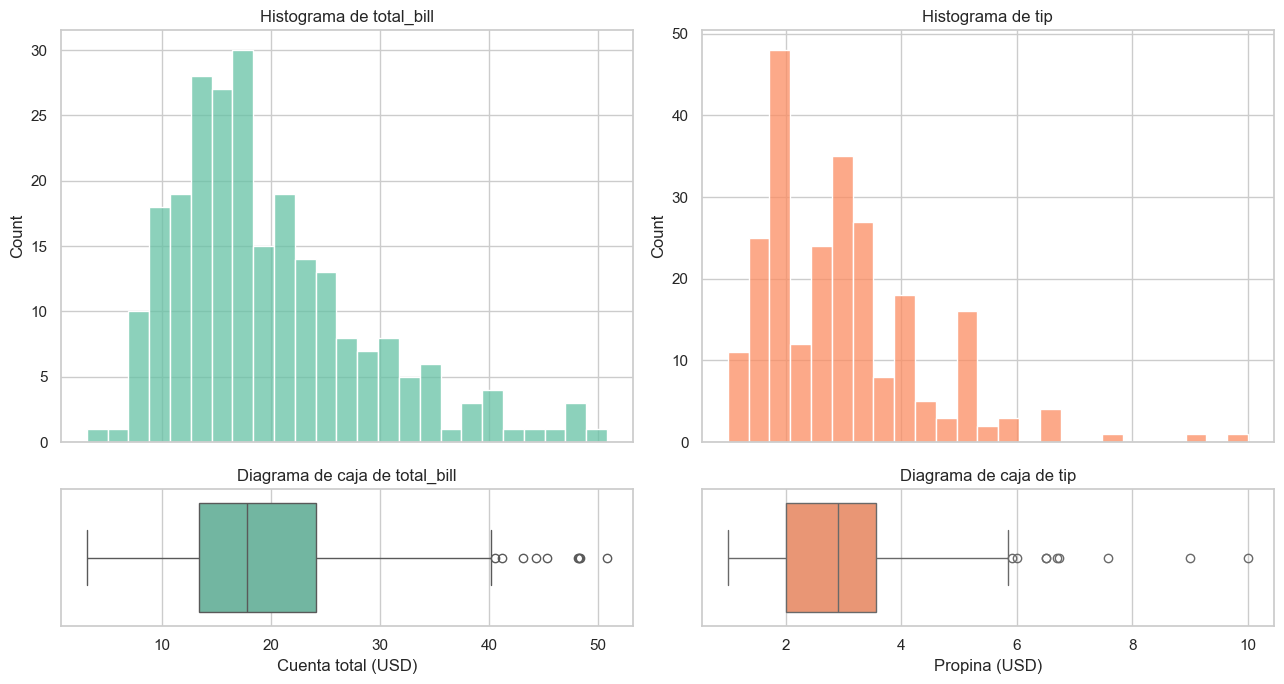

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex="col", gridspec_kw={"height_ratios": [3, 1]})
for j, (col, etiqueta) in enumerate([("total_bill", "Cuenta total (USD)"), ("tip", "Propina (USD)")]):
    color = sns.color_palette()[j]
    sns.histplot(tips[col], bins=25, ax=axes[0, j], color=color)
    axes[0, j].set_title(f"Histograma de {col}")
    axes[0, j].set_xlabel("")
    sns.boxplot(x=tips[col], ax=axes[1, j], color=color)
    axes[1, j].set_title(f"Diagrama de caja de {col}")
    axes[1, j].set_xlabel(etiqueta)
fig.tight_layout()
plt.show()

**Análisis**

- **Histograma:** muestra la **forma completa** de la distribución: ambas variables tienen asimetría a la derecha con una cola larga. En `tip` además se ven picos en valores redondos (2, 3, 4, 5). Su aspecto depende del número de intervalos elegido.
- **Diagrama de caja:** resume la distribución con cinco números (mediana, cuartiles y bigotes) y **marca los valores atípicos**, que aparecen solo del lado derecho. Es compacto y muy útil para comparar grupos, pero **no muestra la forma** (por ejemplo, los picos de `tip`).
- **Comparación:** el histograma aporta la forma y la concentración de los datos; el diagrama de caja aporta los cuantiles, la dispersión (RIC) y los valores extremos. Juntos confirman la asimetría a la derecha.


#### 2.4 `total_bill` por `time` y por `day`

In [40]:
orden_dia = ["Thur", "Fri", "Sat", "Sun"]

def resumen_grupo(s):
    return pd.Series({
        "n": s.size, "media": s.mean(), "mediana": s.median(), "desv. est.": s.std(),
        "RIC": s.quantile(0.75) - s.quantile(0.25),
        "asimetría": stats.skew(s, bias=False), "curtosis exc.": stats.kurtosis(s, bias=False),
    })

por_time = tips.groupby("time")["total_bill"].apply(resumen_grupo).unstack()
por_day = tips.groupby("day")["total_bill"].apply(resumen_grupo).unstack().reindex(orden_dia)
for t in (por_time, por_day):
    t["n"] = t["n"].astype(int)

print("total_bill por time:")
display(por_time)
print("total_bill por day:")
display(por_day)

total_bill por time:


,n,media,mediana,desv. est.,RIC,asimetría,curtosis exc.
time,,,,,,,
Dinner,176,20.797,18.390,9.142,10.845,1.034,1.036
Lunch,68,17.169,15.965,7.714,7.297,1.475,2.206


total_bill por day:


,n,media,mediana,desv. est.,RIC,asimetría,curtosis exc.
day,,,,,,,
Thur,62,17.683,16.200,7.886,7.713,1.361,1.820
Fri,19,17.152,15.380,8.303,9.655,1.317,1.994
Sat,87,20.441,18.240,9.480,10.835,1.262,1.716
Sun,76,21.410,19.630,8.832,10.610,0.823,0.422


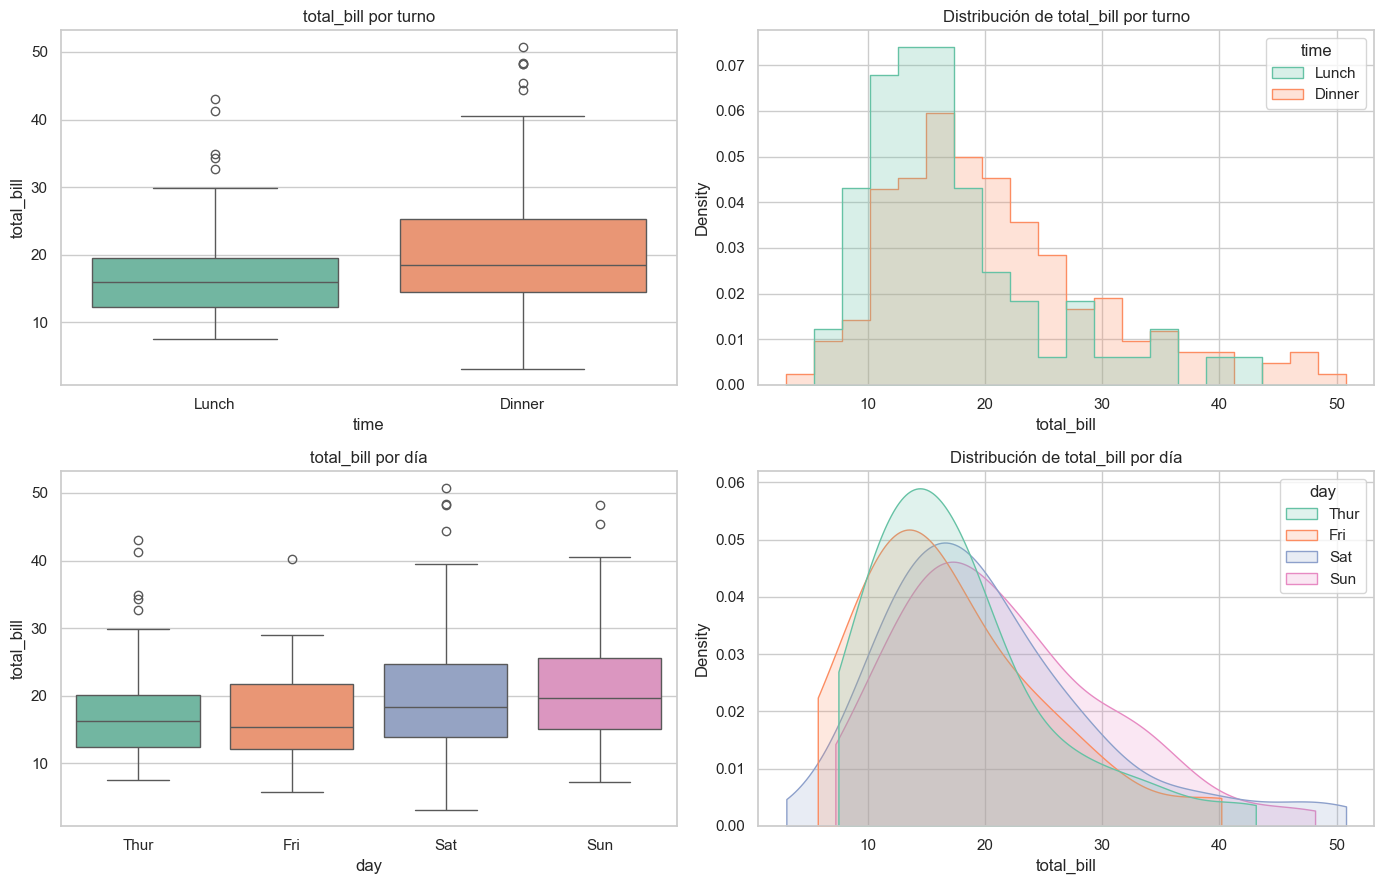

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(data=tips, x="time", y="total_bill", hue="time", legend=False, order=["Lunch", "Dinner"], hue_order=["Lunch", "Dinner"], ax=axes[0, 0])
axes[0, 0].set_title("total_bill por turno")
sns.histplot(data=tips, x="total_bill", hue="time", hue_order=["Lunch", "Dinner"], stat="density", common_norm=False, element="step", bins=20, ax=axes[0, 1])
axes[0, 1].set_title("Distribución de total_bill por turno")

sns.boxplot(data=tips, x="day", y="total_bill", hue="day", legend=False, order=orden_dia, hue_order=orden_dia, ax=axes[1, 0])
axes[1, 0].set_title("total_bill por día")
sns.kdeplot(data=tips, x="total_bill", hue="day", hue_order=orden_dia, common_norm=False, fill=True, alpha=0.2, cut=0, ax=axes[1, 1])
axes[1, 1].set_title("Distribución de total_bill por día")

fig.tight_layout()
plt.show()

**Análisis**

**Por `time`:** las cenas tienen cuentas mayores y más dispersas que los almuerzos: mediana 18.39 vs 15.97, media 20.80 vs 17.17, desviación 9.14 vs 7.71 y RIC 10.85 vs 7.30. Ambas distribuciones son asimétricas a la derecha (1.03 en cenas y 1.48 en almuerzos). En el histograma se ve que los almuerzos se concentran en cuentas más bajas y las cenas tienen la cola derecha más larga (hasta 50.81).

**Por `day`:** las medianas son jueves 16.20, viernes 15.38, sábado 18.24 y domingo 19.63 (medias 17.68, 17.15, 20.44 y 21.41). Sábado y domingo tienen cuentas más altas y más dispersas (RIC de 10.84 y 10.61, contra 7.71 en jueves). El domingo es el día menos asimétrico (0.82) y el viernes tiene solo 19 mesas, por lo que sus estadísticos son poco fiables. En las densidades se ve el desplazamiento hacia la derecha de sábado y domingo respecto a jueves y viernes.


#### 2.5 Transformación logarítmica de `total_bill`

In [42]:
tips["log_total_bill"] = np.log(tips["total_bill"])

pd.DataFrame({
    "asimetría": [stats.skew(tips["total_bill"], bias=False), stats.skew(tips["log_total_bill"], bias=False)],
}, index=["total_bill", "log(total_bill)"])

,asimetría
total_bill,1.133
log(total_bill),-0.116


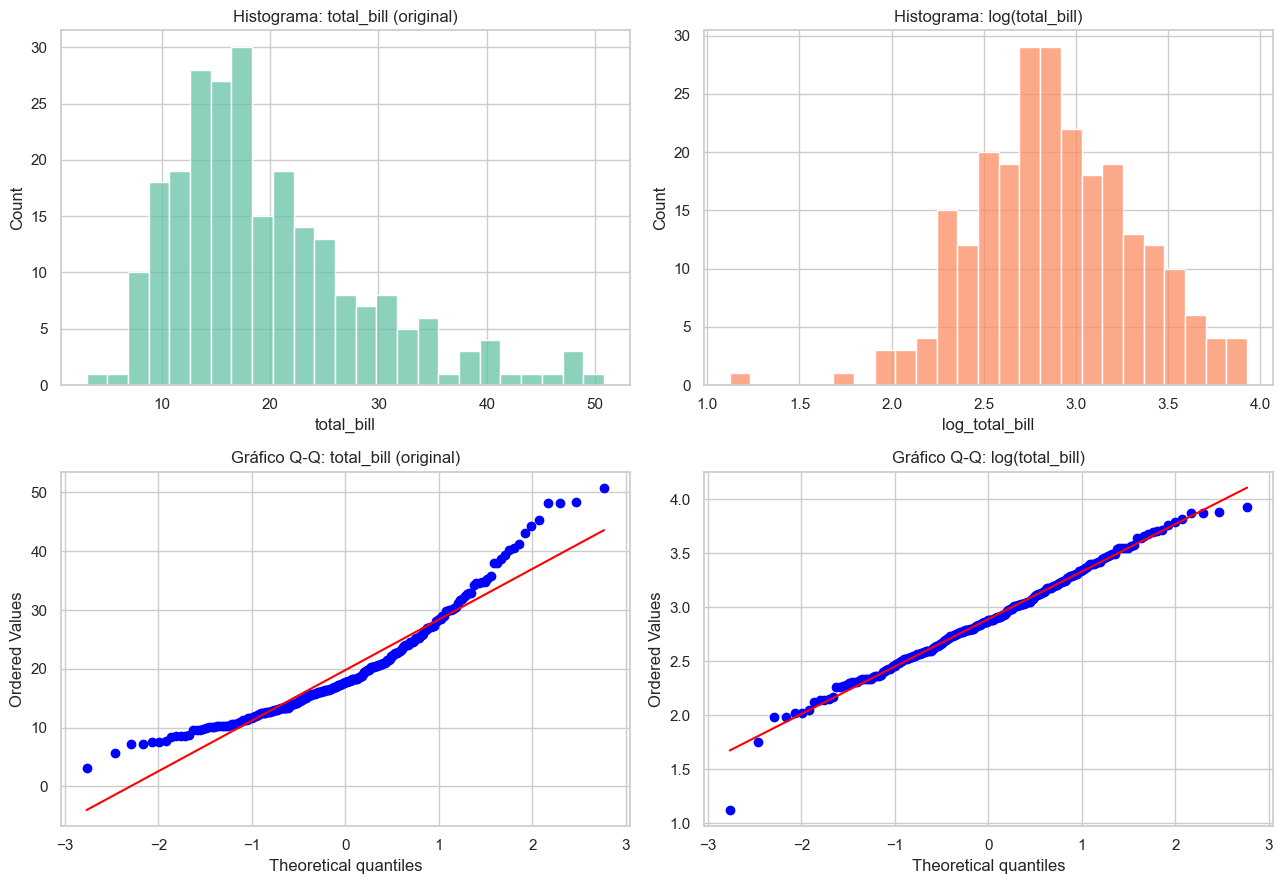

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for j, (col, titulo) in enumerate([("total_bill", "total_bill (original)"), ("log_total_bill", "log(total_bill)")]):
    sns.histplot(tips[col], bins=25, ax=axes[0, j], color=sns.color_palette()[j])
    axes[0, j].set_title(f"Histograma: {titulo}")
    stats.probplot(tips[col], dist="norm", plot=axes[1, j])
    axes[1, j].set_title(f"Gráfico Q-Q: {titulo}")
fig.tight_layout()
plt.show()

**Análisis**

- **Asimetría:** pasa de **1.13** en `total_bill` a **−0.12** en `log(total_bill)`; la transformación elimina casi toda la asimetría.
- **Histograma:** de una distribución con cola larga a la derecha se pasa a una forma de campana casi simétrica.
- **Gráfico Q-Q:** en la escala original los puntos forman una curva que se separa de la recta, con la cola derecha muy por encima de lo esperado en una normal; tras el logaritmo los puntos quedan casi sobre la recta, con pequeñas desviaciones solo en los extremos.
- **Conclusión:** `total_bill` es aproximadamente lognormal, algo esperable en una variable positiva con efectos multiplicativos. Al trabajar con `log(total_bill)`, los resultados deben interpretarse en escala logarítmica (cambios relativos).


#### 2.6 `size` como conteo discreto

,n,proporción
size,,
1,4,0.016
2,156,0.639
3,38,0.156
4,37,0.152
5,5,0.020
6,4,0.016


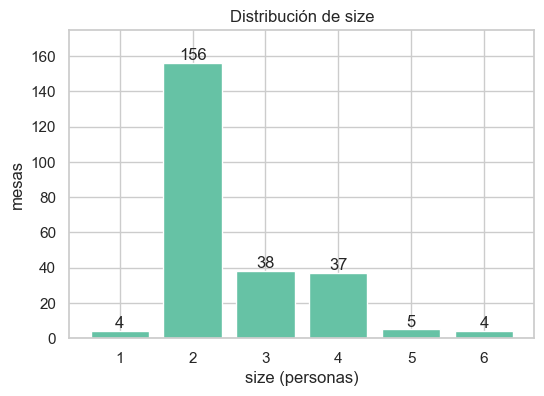

In [44]:
conteo = tips["size"].value_counts().sort_index()
display(pd.DataFrame({"n": conteo, "proporción": conteo / conteo.sum()}))

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(conteo.index, conteo.values, color=sns.color_palette()[0])
ax.bar_label(barras)
ax.set_xticks(conteo.index)
ax.set_ylim(0, conteo.max() * 1.12)
ax.set_xlabel("size (personas)")
ax.set_ylabel("mesas")
ax.set_title("Distribución de size")
plt.show()

**Análisis**

`size` es un **conteo**: cuenta personas, solo toma valores enteros de 1 a 6 y no existen valores intermedios (no hay una mesa de 2.5 personas). Por eso hay que analizarla con herramientas de variables discretas:

- **Se describe con su tabla de frecuencias y un gráfico de barras separadas.** Las mesas de 2 personas dominan (156, 63.9 %), seguidas de 3 (38, 15.6 %) y 4 (37, 15.2 %); las de 1, 5 y 6 son muy raras (4, 5 y 4 mesas).
- **Tratarla como continua no tiene sentido.** Un histograma con intervalos arbitrarios o una curva de densidad suavizada reparte probabilidad entre los enteros y fuera del rango posible, y estadísticos como la asimetría o la curtosis, o supuestos como la normalidad, pierden su interpretación en un soporte de solo 6 valores. Además, la media (2.57) no es un valor que la variable pueda tomar, mientras que la moda y la mediana (2) sí.
- **En modelado**, los conteos se tratan con distribuciones discretas (por ejemplo, Poisson) o como categorías ordenadas, no como una variable continua cualquiera.
